In [ ]:
### Tips: ### 
## Looking at gene names cell names ##
# rna_adata.var_names # genes
# rna_adata.obs_names # cells
# rna_adata.X[]

In [64]:
## Save genes - to then convert to ensemble IDs ##
# gene_names = rna_adata.var_names
# gene_names

In [67]:
## Saving genes for Biomart
# with open("genes.txt", "w") as f:
#     for gene in gene_names:
#         f.write(gene + "\n")

In [13]:
# import numpy as np
# import pandas as pd
# import gc
# import scanpy as sc
# import muon as mu
# from scipy.sparse import issparse, diags, csr_matrix
# from sklearn.decomposition import TruncatedSVD
# import tensorflow as tf
# from sklearn.model_selection import KFold
# from sklearn.metrics import accuracy_score

# # Change this to your local path where the data files are stored
# DATA_PATH = '/home/sofia/Citeseq-Hackathon/Dataset/'

In [3]:
# ipykernel: scvi_sofia

import numpy as np
import pandas as pd
import gc
import scanpy as sc
import muon as mu
import scvi
from scipy.sparse import issparse, diags, csr_matrix

from sklearn.metrics import silhouette_score, adjusted_mutual_info_score

# Change this to your local path where the data files are stored
DATA_PATH = '/home/sofia/Citeseq-Hackathon/Dataset/'

/home/miniconda3/envs/scvi_sofia/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/miniconda3/envs/scvi_sofia/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [ ]:
# Saving count data
# adata.layers["counts"] = adata.X.copy()

In [5]:
mu.set_options(pull_on_update=False)

In [6]:
# get data
mdata = mu.read(DATA_PATH + 'GSE194315_binarized_mu.h5mu')

In [7]:
print(f'MuData: {mdata.shape}')
print(f'Modalities: {list(mdata.mod.keys())}')

MuData: (180794, 33951)
Modalities: ['rna', 'protein']


In [8]:
# Extract RNA and ADT modalities
rna_adata = mdata.mod['rna']
adt_adata = mdata.mod['protein']
print(f'RNA: {rna_adata.shape} (cells x genes), sparse={issparse(rna_adata.X)}')
print(f'ADT: {adt_adata.shape} (cells x proteins)')

RNA: (180794, 33694) (cells x genes), sparse=True
ADT: (180794, 257) (cells x proteins)


In [10]:
# Saving count data
rna_adata.layers["counts"] = rna_adata.X.copy()

In [22]:
rna_adata

AnnData object with n_obs × n_vars = 180794 × 33694
    obs: 'sample', 'batch_ID', 'Sample', 'Run', 'Subject', 'Status', 'DemuxletDropletType', 'IncludedInStudy', 'CellType', 'Cluster'
    layers: 'counts'

In [11]:
# Normalizing to median total counts
sc.pp.normalize_total(rna_adata)

In [12]:
# Logarithmize the data
sc.pp.log1p(rna_adata)

In [13]:
rna_adata

AnnData object with n_obs × n_vars = 180794 × 33694
    obs: 'sample', 'batch_ID', 'Sample', 'Run', 'Subject', 'Status', 'DemuxletDropletType', 'IncludedInStudy', 'CellType', 'Cluster'
    uns: 'log1p'
    layers: 'counts'

In [14]:
rna_adata.X.max()

np.float32(8.285844)

In [15]:
sc.tl.pca(rna_adata)

In [16]:
rna_adata

AnnData object with n_obs × n_vars = 180794 × 33694
    obs: 'sample', 'batch_ID', 'Sample', 'Run', 'Subject', 'Status', 'DemuxletDropletType', 'IncludedInStudy', 'CellType', 'Cluster'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [17]:
# Goal: 180794 by 50
rna_adata.obsm["X_pca"]

array([[-4.16429186e+00,  9.14083862e+00, -8.63341749e-01, ...,
        -1.14619069e-01, -2.94626653e-01,  4.24410850e-01],
       [ 1.23514128e+01, -2.81670761e+00, -4.91839170e+00, ...,
         3.24743330e-01, -6.10280037e-01, -4.54035491e-01],
       [-5.37778330e+00, -2.38091755e+00, -6.30305147e+00, ...,
         4.56216097e-01,  8.31531361e-03,  3.51540327e-01],
       ...,
       [ 1.53168526e+01, -1.78643072e+00,  1.21886909e+00, ...,
         4.58781391e-01,  1.24794558e-01, -1.62152469e-01],
       [-4.60526657e+00,  5.92950726e+00, -1.80489802e+00, ...,
        -2.35817693e-02, -3.60639453e-01, -8.19890127e-02],
       [-8.74165535e+00, -4.73831701e+00, -2.54328847e+00, ...,
        -5.60886741e-01,  1.05496846e-01,  8.16825032e-01]],
      shape=(180794, 50), dtype=float32)

In [18]:
rna_adata.obsm["X_pca"].shape

(180794, 50)

In [19]:
# example of the first PCA:
rna_adata.obsm["X_pca"][:, 0]

array([-4.164292 , 12.351413 , -5.3777833, ..., 15.316853 , -4.6052666,
       -8.741655 ], shape=(180794,), dtype=float32)

In [20]:
# save PCA into .npy file
np.save("X_pca.npy", rna_adata.obsm["X_pca"])

In [22]:
# setting up the model
# scvi.model.SCVI.setup_anndata(rna_adata, layer="counts", batch_key="batch")
scvi.model.SCVI.setup_anndata(rna_adata, layer="counts")

# initialize model
model = scvi.model.SCVI(rna_adata)

# train model
model.train()

# get latent representation
latent = model.get_latent_representation()

rna_adata.obsm["X_scvi"] = latent

rna_adata.obsm["X_scvi"].shape

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/miniconda3/envs/scvi_sofia/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.


Epoch 44/44: 100%|██████████| 44/44 [19:31<00:00, 26.61s/it, v_num=1, train_loss=4.78e+3]

`Trainer.fit` stopped: `max_epochs=44` reached.


Epoch 44/44: 100%|██████████| 44/44 [19:31<00:00, 26.63s/it, v_num=1, train_loss=4.78e+3]


(180794, 10)

In [23]:
# save embedding
np.save("X_scvi.npy", rna_adata.obsm["X_scvi"])

In [24]:
# setting up the model - set the number of dimentions to 30
model30 = scvi.model.SCVI(rna_adata, n_latent=30) # 30 is the number of dimentions 

# train model
model30.train()

# get latent representation
latent30 = model30.get_latent_representation()

rna_adata.obsm["X_scvi30"] = latent30

rna_adata.obsm["X_scvi30"].shape

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/miniconda3/envs/scvi_sofia/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.


Epoch 44/44: 100%|██████████| 44/44 [18:33<00:00, 25.78s/it, v_num=1, train_loss=4.76e+3]

`Trainer.fit` stopped: `max_epochs=44` reached.


Epoch 44/44: 100%|██████████| 44/44 [18:33<00:00, 25.30s/it, v_num=1, train_loss=4.76e+3]


(180794, 30)

In [27]:
# save embedding - w 30 dims
np.save("X_scvi_30dims.npy", rna_adata.obsm["X_scvi30"])

In [1]:
rna_adata

NameError: name 'rna_adata' is not defined

In [6]:
rna_adata = sc.read_h5ad("PCA_and_scVI_results.h5ad")
scgpt_adata = sc.read_h5ad("scGPT_results.h5ad")

In [8]:
rna_adata

AnnData object with n_obs × n_vars = 180794 × 33694
    obs: 'sample', 'batch_ID', 'Sample', 'Run', 'Subject', 'Status', 'DemuxletDropletType', 'IncludedInStudy', 'CellType', 'Cluster', '_scvi_batch', '_scvi_labels', 'cluster_is_na', 'silhouette', 'leiden', 'leiden_1', 'leiden_1_scVI', 'leiden_1_scVI30'
    uns: 'CellType_colors', 'Cluster_colors', 'Sample_colors', 'UMAP_scVI', 'UMAP_scVI30', '_scvi_manager_uuid', '_scvi_uuid', 'kNN_PCA', 'kNN_scVI', 'kNN_scVI30', 'leiden', 'leiden_1', 'leiden_1_colors', 'leiden_1_scVI', 'leiden_1_scVI30', 'leiden_1_scVI30_colors', 'leiden_1_scVI_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'UMAP_scVI', 'UMAP_scVI30', 'X_pca', 'X_scvi', 'X_scvi30', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances', 'kNN_PCA_connectivities', 'kNN_PCA_distances', 'kNN_scVI30_connectivities', 'kNN_scVI30_distances', 'kNN_scVI_connectivities', 'kNN_scVI_distances'

In [9]:
scgpt_adata

AnnData object with n_obs × n_vars = 180794 × 2000
    obs: 'sample', 'batch_ID', 'Sample', 'Run', 'Subject', 'Status', 'DemuxletDropletType', 'IncludedInStudy', 'CellType', 'Cluster', 'n_genes', 'total_counts'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'index', 'id_in_vocab'
    uns: 'hvg', 'log1p'
    obsm: 'X_scGPT'
    layers: 'counts'

In [47]:
# # PCA-> UMAP -> cluster 
# sc.tl.pca(rna_adata) 
# sc.pp.neighbors(rna_adata)
# sc.tl.umap(rna_adata)
# sc.pl.umap(
#     rna_adata,
#     color="CellType",
#     # Setting a smaller point size to get prevent overlap
#     size=2,
# )

In [ ]:
# ---- PCA embedding ----
sc.tl.pca(rna_adata)
sc.pp.neighbors(rna_adata, use_rep="X_pca", key_added='kNN_PCA')

In [71]:
sc.tl.leiden(
        rna_adata,
        resolution=1,
        key_added='leiden_1',
        use_weights=True,
        neighbors_key='kNN_PCA',
        flavor='igraph'
    )
sc.tl.umap(rna_adata)

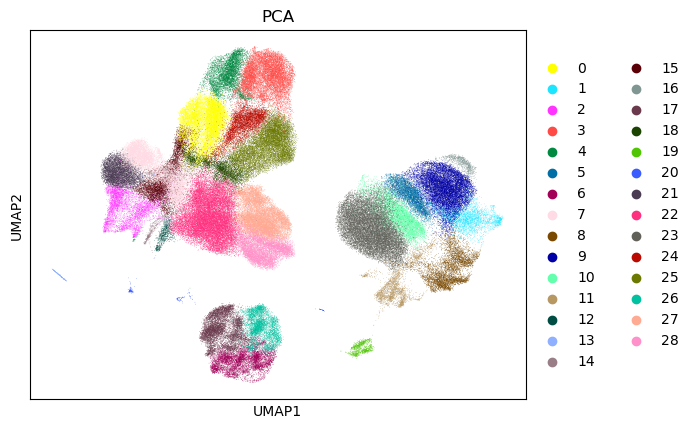

In [72]:
sc.pl.umap(rna_adata, color="leiden_1", title="PCA")

In [73]:
# ----- scVI embedding (default) ---- 
sc.pp.neighbors(rna_adata, use_rep="X_scvi", key_added='kNN_scVI')
sc.tl.leiden(
        rna_adata,
        resolution=1,
        random_state=42,
        key_added=f'leiden_1_scVI',
        use_weights=True,
        n_iterations=-1,
        neighbors_key='kNN_scVI',
        flavor='igraph',
    )
sc.tl.umap(rna_adata, neighbors_key='kNN_scVI', key_added='UMAP_scVI')

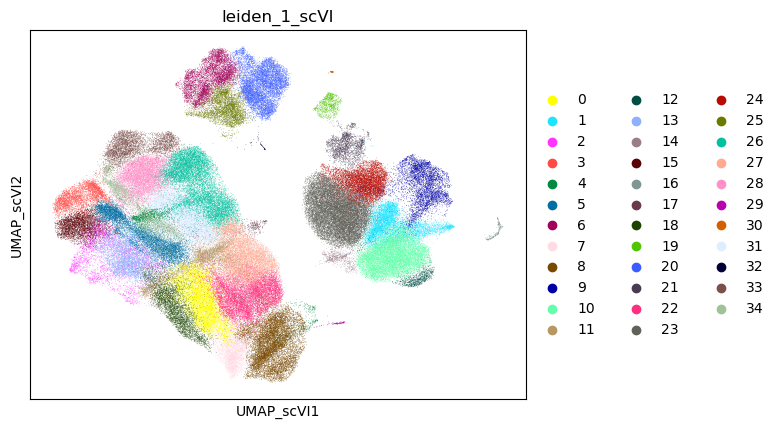

In [77]:
# sc.pl.embedding is the same sc.pl.umap, but wo the X_PCA embedding hardcoded 
sc.pl.embedding(
        adata=rna_adata,
        basis='UMAP_scVI',
        neighbors_key='kNN_scVI',
        color="leiden_1_scVI"
    )

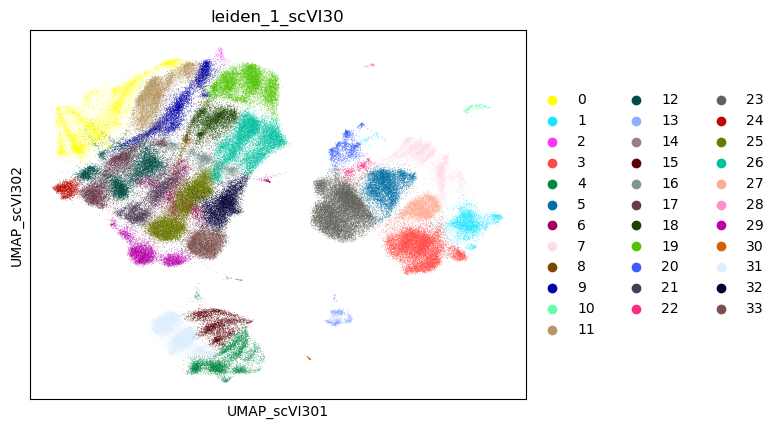

In [117]:
# ----- scVI embedding (30 dims) ---- 
sc.pp.neighbors(rna_adata, use_rep="X_scvi30", key_added='kNN_scVI30')
sc.tl.leiden(
        rna_adata,
        resolution=1,
        random_state=42,
        key_added='leiden_1_scVI30',
        use_weights=True,
        n_iterations=-1,
        neighbors_key='kNN_scVI30',
        flavor='igraph',
    )
sc.tl.umap(rna_adata, neighbors_key='kNN_scVI30', key_added='UMAP_scVI30')

# sc.pl.embedding is the same sc.pl.umap, but wo the X_PCA embedding hardcoded 
sc.pl.embedding(
        adata=rna_adata,
        basis='UMAP_scVI30',
        neighbors_key='kNN_scVI30',
        color="leiden_1_scVI30"
    )

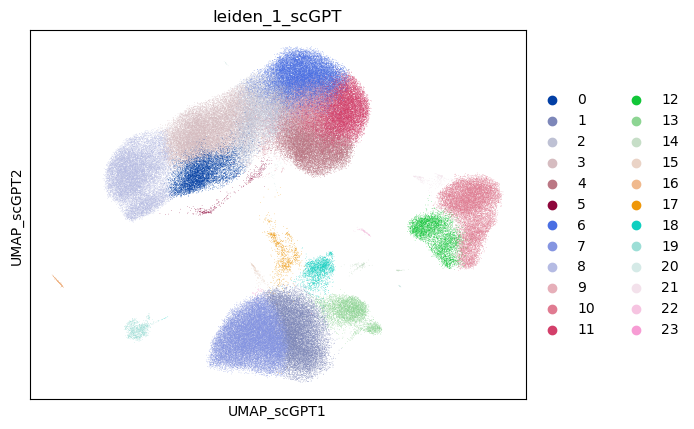

In [12]:
# ----- scGPT embedding ---- 
sc.pp.neighbors(scgpt_adata, use_rep="X_scGPT", key_added='kNN_scGPT') # key_added is basically a label
sc.tl.leiden(
        scgpt_adata,
        resolution=1,
        random_state=42,
        key_added='leiden_1_scGPT',
        use_weights=True,
        n_iterations=-1,
        neighbors_key='kNN_scGPT',
        flavor='igraph',
    )

sc.tl.umap(scgpt_adata, neighbors_key='kNN_scGPT', key_added='UMAP_scGPT')

# sc.pl.embedding is the same sc.pl.umap, but wo the X_PCA embedding hardcoded 
sc.pl.embedding(
        adata=scgpt_adata,
        basis='UMAP_scGPT',
        neighbors_key='kNN_scGPT',
        color="leiden_1_scGPT"
    )

In [91]:
# ------------------------------
# ------ Silhouette score ------
# ------------------------------
# -- looking at the cluster stability --
# Conclustion: all embeddings showed a similar cluster stability - no clear winner (scVI showed overall good performance). 
# AMI score helps to tell how similar (which cells make up a cluster) are clusters labels to between each other 
# --> we can compare labels from unsupervised clustering (leiden) against cell types 
# Silhouette score - to check how well are clusters defined

In [27]:
# -------- Silhouette score for PCA: --------
silhouette = silhouette_score(rna_adata.obsm['X_pca'], rna_adata.obs['leiden_1'])

In [28]:
silhouette

0.06481964141130447

In [29]:
# -------- Silhouette score for scVI: --------
silhouette_scVI = silhouette_score(rna_adata.obsm['X_scvi'], rna_adata.obs['leiden_1_scVI'])

In [30]:
silhouette_scVI # ⭐️ - compare the winner against the ground truth

0.10244276374578476

In [ ]:
# -------- Silhouette score for scVI30: --------

In [23]:
silhouette_scVI30 = silhouette_score(rna_adata.obsm['X_scvi30'], rna_adata.obs['leiden_1_scVI30'])

In [24]:
silhouette_scVI30

0.06546297669410706

In [ ]:
# -------- Silhouette score for scGPT: -------- 

In [14]:
silhouette_scGPT = silhouette_score(scgpt_adata.obsm['X_scGPT'], scgpt_adata.obs['leiden_1_scGPT'])

In [15]:
silhouette_scGPT

0.09233823418617249

In [ ]:
# ------------------------
# ------ AMI score -------

In [123]:
# --- How similar are clusters among each other -----
AMI = adjusted_mutual_info_score(rna_adata.obs['leiden_1'], rna_adata.obs['leiden_1_scVI'])
AMI

0.791979671554273

In [121]:
# --- How similar are clusters among each other -----
AMI = adjusted_mutual_info_score(rna_adata.obs['leiden_1'], rna_adata.obs['leiden_1_scVI30'])
AMI

0.8019505209212314

In [122]:
# --- How similar are clusters among each other -----
AMI = adjusted_mutual_info_score(rna_adata.obs['leiden_1_scVI'], rna_adata.obs['leiden_1_scVI30'])
AMI

0.7927537090378262

In [32]:
# --- How similar are clusters among each other -----
AMI = adjusted_mutual_info_score(rna_adata.obs['leiden_1_scVI'], scgpt_adata.obs['CellType'])
AMI

0.6279541135043524

In [22]:
# --- How similar are clusters among each other -----
AMI = adjusted_mutual_info_score(scgpt_adata.obs['leiden_1_scGPT'], scgpt_adata.obs['CellType'])
AMI

0.6092703729994786

In [17]:
rna_adata

AnnData object with n_obs × n_vars = 180794 × 33694
    obs: 'sample', 'batch_ID', 'Sample', 'Run', 'Subject', 'Status', 'DemuxletDropletType', 'IncludedInStudy', 'CellType', 'Cluster', '_scvi_batch', '_scvi_labels', 'cluster_is_na', 'silhouette', 'leiden', 'leiden_1', 'leiden_1_scVI', 'leiden_1_scVI30'
    uns: 'CellType_colors', 'Cluster_colors', 'Sample_colors', 'UMAP_scVI', 'UMAP_scVI30', '_scvi_manager_uuid', '_scvi_uuid', 'kNN_PCA', 'kNN_scVI', 'kNN_scVI30', 'leiden', 'leiden_1', 'leiden_1_colors', 'leiden_1_scVI', 'leiden_1_scVI30', 'leiden_1_scVI30_colors', 'leiden_1_scVI_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'UMAP_scVI', 'UMAP_scVI30', 'X_pca', 'X_scvi', 'X_scvi30', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances', 'kNN_PCA_connectivities', 'kNN_PCA_distances', 'kNN_scVI30_connectivities', 'kNN_scVI30_distances', 'kNN_scVI_connectivities', 'kNN_scVI_distances'

In [ ]:
# ----------------------------------------------------------
# Check if clustering match our cell types (ground truth) -- 
# ----------------------------------------------------------

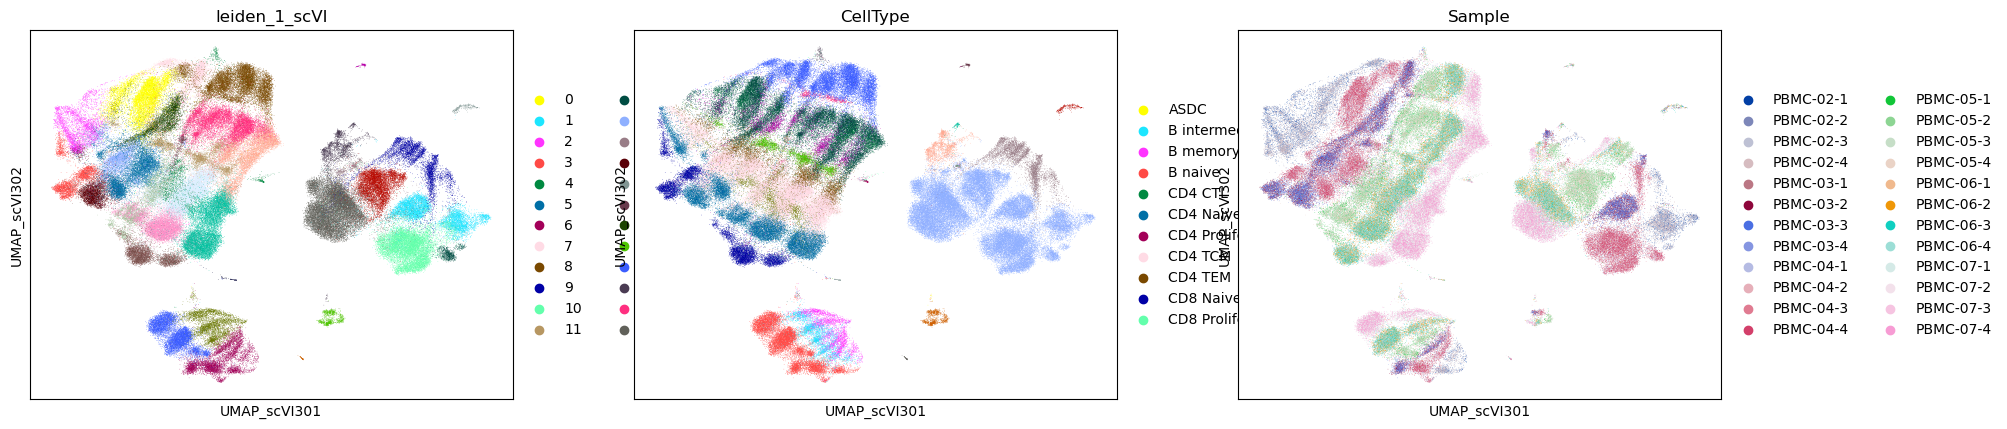

In [120]:
# sc.pl.embedding is the same sc.pl.umap, but wo the X_PCA embedding hardcoded 
sc.pl.embedding(
        adata=rna_adata,
        basis='UMAP_scVI30',
        neighbors_key='kNN_scVI',
        color=["leiden_1_scVI30", "CellType", "Sample"]
    )

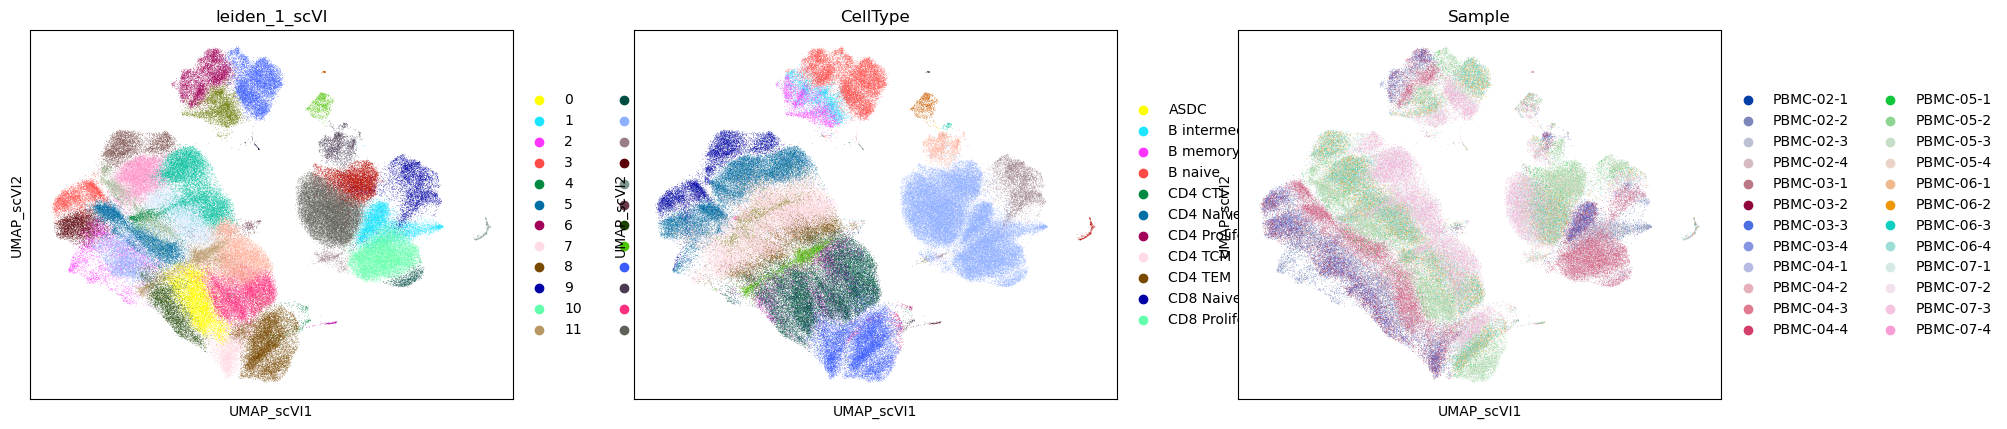

In [104]:
# sc.pl.embedding is the same sc.pl.umap, but wo the X_PCA embedding hardcoded 
sc.pl.embedding(
        adata=rna_adata,
        basis='UMAP_scVI',
        neighbors_key='kNN_scVI',
        color=["leiden_1_scVI", "CellType", "Sample"]
    )

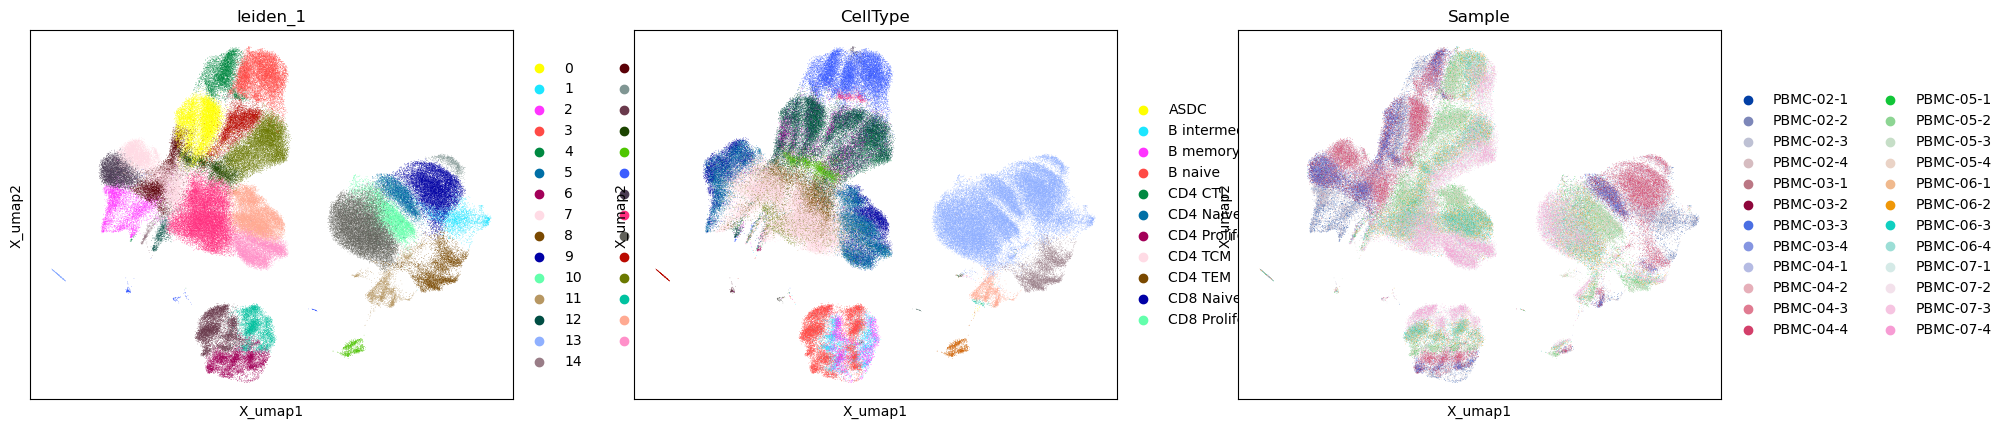

In [114]:
# sc.pl.embedding is the same sc.pl.umap, but wo the X_PCA embedding hardcoded 
sc.pl.embedding(
        adata=rna_adata,
        basis='X_umap',
        neighbors_key='kNN_scVI',
        color=["leiden_1", "CellType", "Sample"]
    )

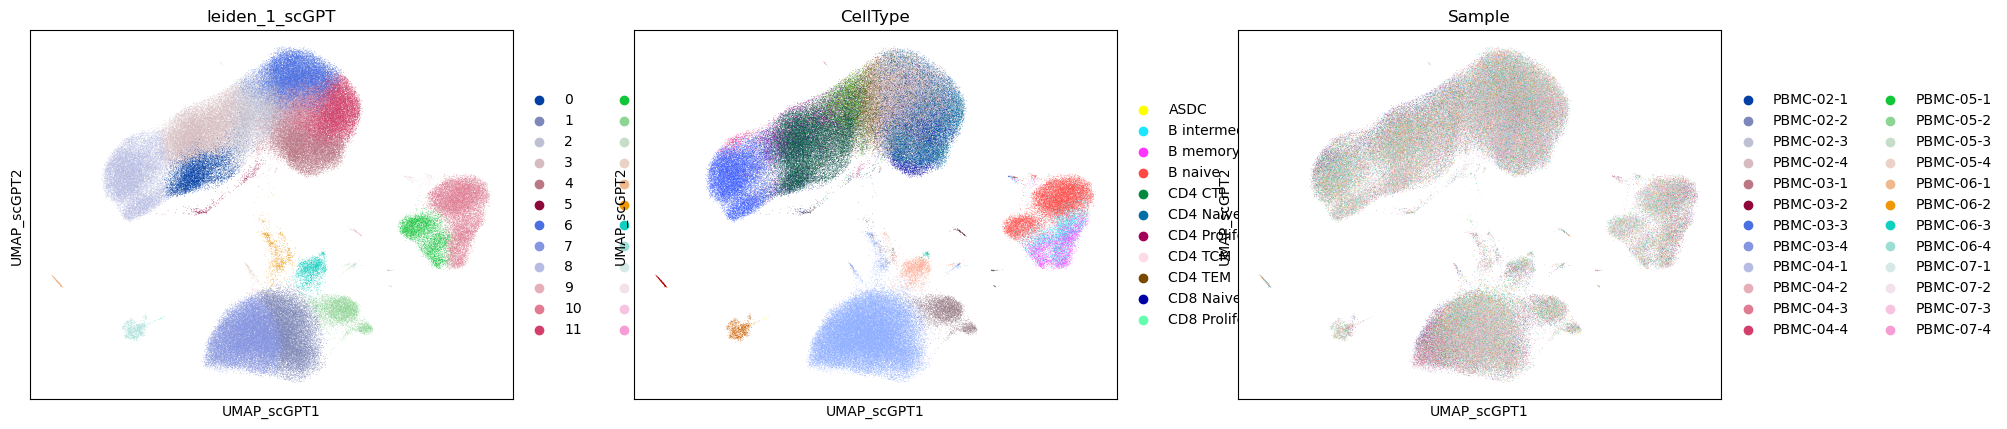

In [16]:
# sc.pl.embedding is the same sc.pl.umap, but wo the X_PCA embedding hardcoded 
sc.pl.embedding(
        adata=scgpt_adata,
        basis='UMAP_scGPT',
        neighbors_key='kNN_scGPT',
        color=["leiden_1_scGPT", "CellType", "Sample"]
    )

In [124]:
rna_adata

AnnData object with n_obs × n_vars = 180794 × 33694
    obs: 'sample', 'batch_ID', 'Sample', 'Run', 'Subject', 'Status', 'DemuxletDropletType', 'IncludedInStudy', 'CellType', 'Cluster', '_scvi_batch', '_scvi_labels', 'cluster_is_na', 'silhouette', 'leiden', 'leiden_1', 'leiden_1_scVI', 'leiden_1_scVI30'
    uns: 'log1p', 'pca', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'sample_colors', 'Cluster_colors', 'CellType_colors', 'kNN_PCA', 'leiden', 'leiden_1', 'leiden_1_colors', 'kNN_scVI', 'leiden_1_scVI', 'UMAP_scVI', 'leiden_1_scVI_colors', 'Sample_colors', 'kNN_scVI30', 'leiden_1_scVI30', 'UMAP_scVI30', 'leiden_1_scVI30_colors'
    obsm: 'X_pca', 'X_scvi', 'X_scvi30', 'X_umap', 'UMAP_scVI', 'UMAP_scVI30'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'kNN_PCA_distances', 'kNN_PCA_connectivities', 'kNN_scVI_distances', 'kNN_scVI_connectivities', 'kNN_scVI30_distances', 'kNN_scVI30_connectivities'

In [130]:
rna_adata.allow_write_nullable_strings = True

In [131]:
# ---------------------------------
# ------- Save adata: -------------
# ---------------------------------
import anndata as ad

ad.settings.allow_write_nullable_strings = True

rna_adata.write_h5ad("PCA_and_scVI_results.h5ad")

In [134]:
# --- Keep only cellID and obsm embeddings:
import anndata as ad
import numpy as np

n_cells = rna_adata.n_obs

new_adata = ad.AnnData(
    X=np.zeros((n_cells, 1))  # placeholder
)

new_adata.obs = rna_adata.obs.copy()

new_adata.obsm = {
    k: v.copy() for k, v in rna_adata.obsm.items()
}

In [137]:
new_adata

AnnData object with n_obs × n_vars = 180794 × 1
    obs: 'sample', 'batch_ID', 'Sample', 'Run', 'Subject', 'Status', 'DemuxletDropletType', 'IncludedInStudy', 'CellType', 'Cluster', '_scvi_batch', '_scvi_labels', 'cluster_is_na', 'silhouette', 'leiden', 'leiden_1', 'leiden_1_scVI', 'leiden_1_scVI30'
    obsm: 'X_pca', 'X_scvi', 'X_scvi30', 'X_umap', 'UMAP_scVI', 'UMAP_scVI30'

In [138]:
new_adata.write_h5ad("PCA_and_scVI_results_small.h5ad")